# Data Sample Length Analysis

Распределение длин **документов** в train-shard’ах (`fineweb_train_*.bin`).

В вашем пайплайне (`data/download_hf_docs_and_tokenize.py`) стоит **`APPEND_EOS = false`** (см. `data/manifest.json`): каждый документ кодируется как **`BOS` + текст**, без отдельного EOS в конце. Поэтому границы восстанавливаются по **`BOS_ID`**, а не по `EOS`.

Если когда‑нибудь включите `append_eos: true`, в ячейке ниже режим `SEGMENT_MODE=auto` переключится на сегментацию по EOS.


In [5]:
import glob
import json
import os
from pathlib import Path

import numpy as np

from train_gpt_lib.data import load_data_shard

try:
    import matplotlib.pyplot as plt

    HAS_MPL = True
except Exception:
    HAS_MPL = False

np.set_printoptions(suppress=True)


In [6]:
# Настройки анализа
DATA_GLOB = os.environ.get("DATA_GLOB", "./data/datasets/fineweb10B_sp1024/fineweb_train_*.bin")
# auto | bos | eos — для fineweb из репо обычно нужен bos (append_eos=false)
SEGMENT_MODE = os.environ.get("SEGMENT_MODE", "auto").strip().lower()
MAX_SHARDS = int(os.environ.get("MAX_SHARDS", "16"))  # 0 => все шарды
MAX_TOKENS_PER_SHARD = int(os.environ.get("MAX_TOKENS_PER_SHARD", "0"))  # 0 => весь шард

shards = sorted(Path(p) for p in glob.glob(DATA_GLOB))
if not shards:
    raise FileNotFoundError(f"Не нашли shard-файлы по маске: {DATA_GLOB}")
if MAX_SHARDS > 0:
    shards = shards[:MAX_SHARDS]

# manifest.json: bos_id, eos_id, append_eos
manifest = None
MANIFEST_PATH = Path(os.environ.get("MANIFEST_PATH", "")) if os.environ.get("MANIFEST_PATH") else None
if MANIFEST_PATH is None or not MANIFEST_PATH.is_file():
    MANIFEST_PATH = shards[0].resolve().parent.parent.parent / "manifest.json"
if MANIFEST_PATH.is_file():
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    print("MANIFEST:", MANIFEST_PATH)
else:
    print("MANIFEST: (не найден)", MANIFEST_PATH)

_tok0 = (manifest.get("tokenizers") or [{}])[0] if manifest else {}
BOS_ID = int(os.environ.get("BOS_ID", _tok0.get("bos_id", 1)))
EOS_ID = int(os.environ.get("EOS_ID", _tok0.get("eos_id", 2)))
APPEND_EOS = bool(manifest.get("append_eos", False)) if manifest else False

if SEGMENT_MODE == "auto":
    SEGMENT_MODE = "eos" if APPEND_EOS else "bos"

print(f"SHARDS_USED: {len(shards)}")
print(f"SEGMENT_MODE: {SEGMENT_MODE} (manifest append_eos={APPEND_EOS})")
print(f"BOS_ID={BOS_ID} EOS_ID={EOS_ID}")
print(f"MAX_TOKENS_PER_SHARD: {MAX_TOKENS_PER_SHARD or 'ALL'}")
print("FIRST_SHARD:", shards[0])


MANIFEST: /home/jovyan/vasiliev/notebooks/parameter-golf/data/manifest.json
SHARDS_USED: 16
SEGMENT_MODE: bos (manifest append_eos=False)
BOS_ID=1 EOS_ID=2
MAX_TOKENS_PER_SHARD: ALL
FIRST_SHARD: data/datasets/fineweb10B_sp1024/fineweb_train_000000.bin


In [7]:
# Длины документов: по BOS (формат [BOS][...]) или по EOS если append_eos=true
tokens_seen = 0
sample_lengths = np.array([], dtype=np.int64)

if SEGMENT_MODE == "eos":
    lengths_list: list[int] = []
    carry = 0
    eos_seen = 0
    for shard in shards:
        t = load_data_shard(shard).numpy()
        if MAX_TOKENS_PER_SHARD > 0:
            t = t[:MAX_TOKENS_PER_SHARD]
        tokens_seen += int(t.size)
        eos_idx = np.flatnonzero(t == EOS_ID)
        eos_seen += int(eos_idx.size)
        if eos_idx.size == 0:
            carry += int(t.size)
            continue
        starts = np.concatenate((np.array([-1], dtype=np.int64), eos_idx))
        seg = np.diff(starts).astype(np.int64)
        seg[0] += carry
        lengths_list.extend(seg.tolist())
        carry = int(t.size - (int(eos_idx[-1]) + 1))
    sample_lengths = np.asarray(lengths_list, dtype=np.int64)
    print(f"TOKENS_SEEN: {tokens_seen:,}")
    print(f"EOS_SEEN: {eos_seen:,}")
    print(f"DOCS_CLOSED_BY_EOS: {sample_lengths.size:,}")
    print(f"OPEN_TAIL_AFTER_LAST_EOS: {carry:,}")
else:
    bos_positions: list[int] = []
    offset = 0
    bos_seen = 0
    prefix_before_first_bos = 0
    for i, shard in enumerate(shards):
        t = load_data_shard(shard).numpy()
        if MAX_TOKENS_PER_SHARD > 0:
            t = t[:MAX_TOKENS_PER_SHARD]
        n = int(t.size)
        tokens_seen += n
        idx = np.flatnonzero(t == BOS_ID)
        bos_seen += int(idx.size)
        if idx.size:
            bos_positions.extend((idx.astype(np.int64) + offset).tolist())
        if i == 0 and idx.size and int(idx[0]) > 0:
            prefix_before_first_bos = int(idx[0])
        offset += n

    bos_arr = np.asarray(bos_positions, dtype=np.int64)
    print(f"TOKENS_SEEN: {tokens_seen:,}")
    print(f"BOS_SEEN: {bos_seen:,}")
    print(f"PREFIX_TOKENS_BEFORE_FIRST_BOS (хвост с прошлого окна/шарда): {prefix_before_first_bos:,}")

    if bos_arr.size < 2:
        raise RuntimeError(
            "Меньше двух BOS в выбранном диапазоне — увеличьте MAX_SHARDS или проверьте BOS_ID / данные."
        )
    sample_lengths = np.diff(bos_arr)
    tail_after_last_bos = int(tokens_seen - int(bos_arr[-1]))
    print(f"DOCS_WITH_BOUNDARY (по разнице соседних BOS): {sample_lengths.size:,}")
    print(f"OPEN_TAIL_LAST_DOC_LEN (от последнего BOS до конца окна, вкл. BOS): {tail_after_last_bos:,}")


TOKENS_SEEN: 1,600,000,000
BOS_SEEN: 1,258,696
PREFIX_TOKENS_BEFORE_FIRST_BOS (хвост с прошлого окна/шарда): 0
DOCS_WITH_BOUNDARY (по разнице соседних BOS): 1,258,695
OPEN_TAIL_LAST_DOC_LEN (от последнего BOS до конца окна, вкл. BOS): 708


LEN_STATS (tokens per doc; граница по BOS→следующий маркер):
  min=52 mean=1271.16 max=280,924
  p    1: 132
  p    5: 182
  p   10: 232
  p   25: 382
  p   50: 748
  p   75: 1,415
  p   90: 2,477
  p   95: 3,646
  p   99: 8,947
  p 99.5: 13,298
  p 99.9: 28,689

Suggested bucket upper bounds (quantiles): [748, 1415, 2477, 3646, 8947]


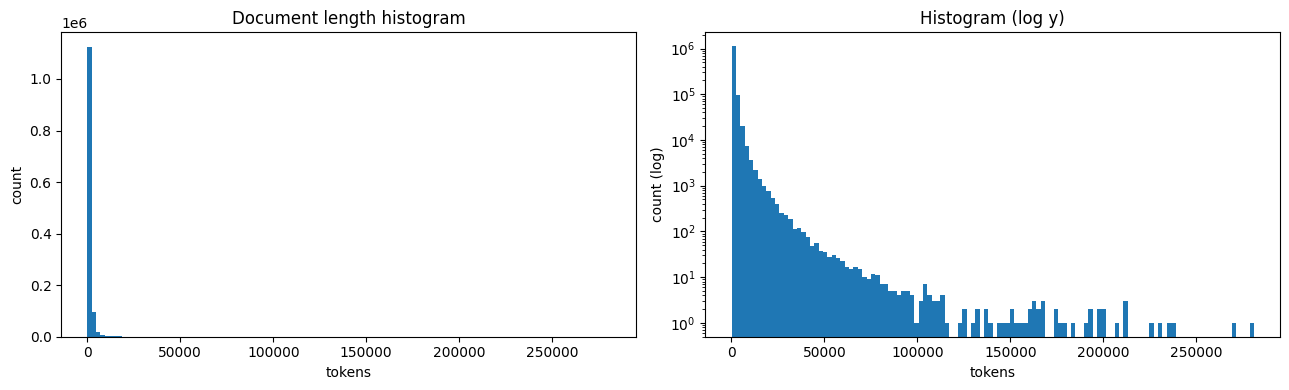

In [8]:
if sample_lengths.size == 0:
    raise RuntimeError(
        "Пустой список длин. Для EOS-режима: нет EOS в данных. Для BOS: слишком мало BOS — расширьте выборку."
    )

unit = "EOS→" if SEGMENT_MODE == "eos" else "BOS→"
q = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
vals = np.percentile(sample_lengths, q)

print(f"LEN_STATS (tokens per doc; граница по {unit}следующий маркер):")
print(f"  min={sample_lengths.min():,} mean={sample_lengths.mean():.2f} max={sample_lengths.max():,}")
for p, v in zip(q, vals):
    print(f"  p{p:>5}: {int(round(v)):,}")

bucket_q = [50, 75, 90, 95, 99]
bucket_bounds = [int(round(v)) for v in np.percentile(sample_lengths, bucket_q)]
print("\nSuggested bucket upper bounds (quantiles):", bucket_bounds)

if HAS_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(sample_lengths, bins=120)
    ax[0].set_title("Document length histogram")
    ax[0].set_xlabel("tokens")
    ax[0].set_ylabel("count")

    ax[1].hist(sample_lengths, bins=120, log=True)
    ax[1].set_title("Histogram (log y)")
    ax[1].set_xlabel("tokens")
    ax[1].set_ylabel("count (log)")
    plt.tight_layout()
    plt.show()
else:
    print("\nmatplotlib не найден; только текстовые статистики.")
